# Activity Plots

In this notebook we will generate some publication ready activity plots generated from our 1 minute bin data between LD and DD.

This data was generated by the `diet_1min_activity_downsample_rollingMean.csv` script. 

The path to the activity file can be found in `../GenerateActivityBins/diet_1min_activity_downsample_rollingMean.csv`.

### In this script, we will:

First, generate actogram plots across all 96 h and all individuals in LD and DD.

## Import dependencies
We will use statsmodels for generalized linear modelling. Additionally setting some plt.rcParams that will help in putting together the multipanel plots in inkscape.

In [1]:
# import deps
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy.stats as stats
# for GLMs
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests # for p-value adjustment
# 
from IPython.display import display

# setting to make svg rendered text editable
plt.rcParams['svg.fonttype'] = 'none'

# Loading the data and setting some global options
Here we load our dataset file. We can see our additional tests in the paths that have been commented out.

The downsample/rolling mean data is the best. All show similar things, but I believe that the other two datasets overestimate activity due to keypoint jitter.
The newest file used has the most aggressive filtering/smoothing of keypoint trajectories and still bins the data just like the other analyses.

We additionally filter the data for day/night and day number, set our color palettes variable, and set some output directory variables.

In [2]:
# load the data with pandas
#file_path = '../GenerateActivityBins/diet_1min_activity.csv'
#file_path = '../GenerateActivityBins/diet_1min_activity_5jitter_50jump_76bout.csv'
file_path = '../GenerateActivityBins/diet_1min_activity_downsample_rollingMean.csv'

df = pd.read_csv(file_path)

# add day/night categorical labels based on ZT time
# night is 16ZT to 0ZT and daytime is between 0 to 16...
df['time_of_day'] = np.where((df['ZT_day'] % 24) < 16, 'day', 'night')

# add day number column based on day, python starts at 0
df['day_num'] = (df['ZT_continuous'] // 24).astype(int)

# set color palettes and names for LD and DD
palette_dict = {'LD-diet': '#EE99AA', 'DD-diet': '#994455'} 

# convert pixels to cm (281 px/cm)
df['distance_cm'] = df['filtered_distance'] / 281.0

# set and create an output directory in the wd for saving plots.
out_dir = './Plots/'
os.makedirs(out_dir, exist_ok=True)

# additional setup output dir in wd for tables
tables_dir = './Tables/'
os.makedirs(tables_dir, exist_ok=True)


# quickly show the df
df.head()


,treatment,replicate,individual,minute_bin,filtered_distance,tracked_frames,tracking_coverage,is_active,ZT_continuous,ZT_day,time_of_day,day_num,distance_cm
0,DD-diet,rep1,1,0,128.000000,1755,0.975000,1,4.900000,4.900000,day,0,0.455516
1,DD-diet,rep1,1,1,112.000000,1793,0.996111,1,4.916667,4.916667,day,0,0.398577
2,DD-diet,rep1,1,2,231.090796,1789,0.993889,1,4.933333,4.933333,day,0,0.822387
3,DD-diet,rep1,1,3,104.000000,1796,0.997778,1,4.950000,4.950000,day,0,0.370107
4,DD-diet,rep1,1,4,80.000000,1763,0.979444,1,4.966667,4.966667,day,0,0.284698


## Actogram
We will make the actogram below. These are "legacy" style plots but with an update. Here we just want to show the activity of all individuals over 4 days. We aren't doing any double plotting or averaging over individuals.

One row (subplot) is the activity of an individual (in cm) (represented by thin vertical lines) across all 96 h.

Also something to note, while we are showing from 0ZT to 96ZT, all of our recordings were started at 4ZT hench why things start a bit after 0 and progress a bit past 96ZT. 

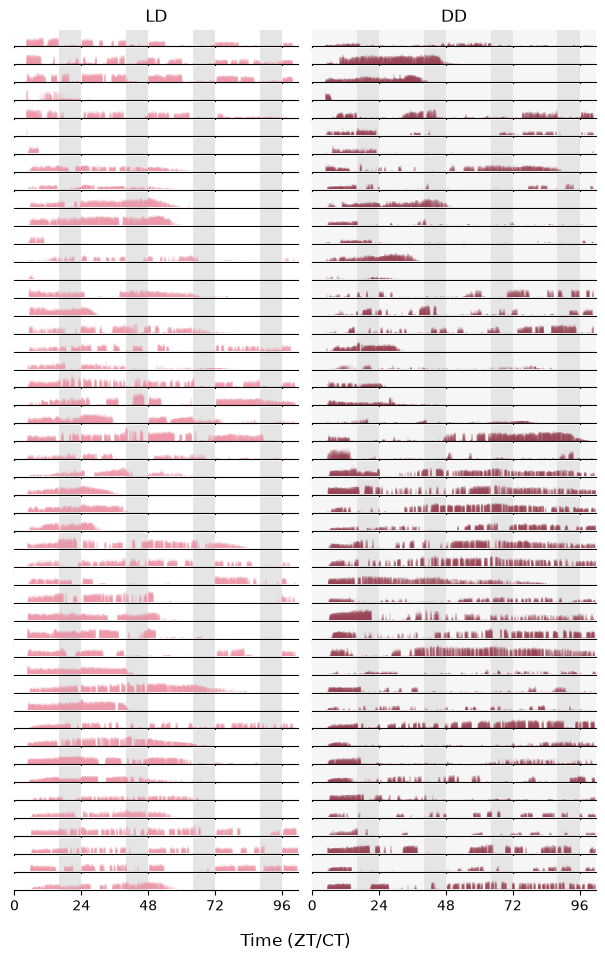

In [3]:
# create a truly unique identifier for each animal and sort the dataframe
df['animal_id'] = df['replicate'].astype(str) + ' - Ind ' + df['individual'].astype(str)
df = df.sort_values(by=['treatment', 'replicate', 'individual', 'ZT_continuous'])

# identify treatments and unique animals per treatment
treatments = df['treatment'].unique()
ld_treat = [t for t in treatments if 'LD' in t.upper()][0] 
dd_treat = [t for t in treatments if 'DD' in t.upper()][0]

inds_ld = list(dict.fromkeys(df[df['treatment'] == ld_treat]['animal_id']))
inds_dd = list(dict.fromkeys(df[df['treatment'] == dd_treat]['animal_id']))

# setup the grid (rows = all individuals per LD/DD, cols = 2 for LD and DD)
n_rows = max(len(inds_ld), len(inds_dd))
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=2, 
    figsize=(7.5, 10), 
    sharex=True, 
    sharey=True, 
    squeeze=False 
)

# get the exact maximum ZT in the dataset to clip the x-axis perfectly at that point
actual_max_zt = df['ZT_continuous'].max()
max_zt_rounded = int(np.ceil(actual_max_zt))

# plot LD (Column 0)
for i, animal in enumerate(inds_ld):
    ax = axes[i, 0]
    data = df[(df['treatment'] == ld_treat) & (df['animal_id'] == animal)]
    
    # use palette_dict set in chunk above to map colors
    ax.vlines(x=data['ZT_continuous'], ymin=0, ymax=data['distance_cm'], 
              color=palette_dict.get(ld_treat, 'black'), linewidth=0.1)
    
    # add vertical grey shading for the night phase (ZT 16-24 of every 24h day)
    for start in range(0, max_zt_rounded + 24, 24):
        ax.axvspan(start + 16, start + 24, color='grey', alpha=0.2, lw=0, zorder=0)
    
    if i == 0:
        ax.set_title("LD") # set title

# plot DD (Column 1)
for i, animal in enumerate(inds_dd):
    ax = axes[i, 1]
    data = df[(df['treatment'] == dd_treat) & (df['animal_id'] == animal)]
    
    # use palette_dict to map colors
    ax.vlines(x=data['ZT_continuous'], ymin=0, ymax=data['distance_cm'], 
              color=palette_dict.get(dd_treat, 'black'), linewidth=0.1)
    
    # add identical "subjective night" shading to DD for visual comparison
    for start in range(0, max_zt_rounded + 24, 24):
        ax.axvspan(start + 16, start + 24, color='grey', alpha=0.2, lw=0, zorder=0)
        # additionally set a light gray for the day since subj. night
        ax.axvspan(start + 0, start + 16, color= 'lightgrey', alpha=0.2, lw=0, zorder=0)
    
    if i == 0:
        ax.set_title("DD") # add title


# clean up the aesthetics
for i in range(n_rows):
    for j in range(2):
        ax = axes[i, j]
        
        # turn off axis entirely if this subplot is empty
        if (j == 0 and i >= len(inds_ld)) or (j == 1 and i >= len(inds_dd)):
            ax.axis('off')
            continue
            
        # remove top, right, and left borders for a minimal look
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        # remove y-axis ticks entirely, too cramped
        ax.set_yticks([])
        ax.margins(x=0)
        
        # force the x-axis to stop exactly at the last available data point, var defined above before LD plotting.
        ax.set_xlim(0, actual_max_zt) 
        
        # dynamically generate ticks every 24 hours strictly within the data limits
        ticks = np.arange(0, actual_max_zt + 1, 24)
        ax.set_xticks(ticks)

# set a single, perfectly centered X-axis label, pulled up slightly to reduce dead space
fig.supxlabel('Time (ZT/CT)', fontsize=12, y=0.04)

# format the spacing a bit
plt.subplots_adjust(
    top=0.96,     
    bottom=0.1,  
    hspace=0.09,   
    wspace=0.05   
) 

plt.savefig(os.path.join(out_dir, 'actogram_96h_pubReady.svg'), format='svg')

plt.show()